### Problem Definition
We want to predict housing prices using features such as:
- Area, Bedrooms, Bathrooms, Stories
- Amenities (mainroad, guestroom, basement, hotwaterheating, airconditioning, parking, prefarea)
- Furnishing status

We will implement **Linear Regression manually** using **Gradient Descent**.
We will also calculate whether predicted prices are an **increase or decrease compared to the average price**, with percentage change.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset (save your pasted data as housing.csv first)
data = pd.read_csv("C:\\Users\\Asus\\OneDrive\\Documents\\GitHub\\basics\\cg project3sem\\Housing (1).csv")
print("Dataset Head:\n", data.head())

Dataset Head:
       price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [19]:
# Encode categorical variables
data_encoded = data.copy()

# Binary encoding for yes/no
binary_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
for col in binary_cols:
    data_encoded[col] = data_encoded[col].map({'yes':1,'no':0})

# Furnishing status encoding
data_encoded['furnishingstatus'] = data_encoded['furnishingstatus'].map({'furnished':2,'semi-furnished':1,'unfurnished':0})

# Features and target
X = data_encoded.drop("price", axis=1).values
y = data_encoded["price"].values

# Store mean/std for features
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_norm = (X - X_mean) / X_std

# Normalize target (important!)
y_mean = y.mean()
y_std = y.std()
y_norm = (y - y_mean) / y_std

# Add bias term
X_norm = np.c_[np.ones(X_norm.shape[0]), X_norm]

# Train-test split
split = int(0.8 * len(X_norm))
X_train, X_test = X_norm[:split], X_norm[split:]
y_train, y_test = y_norm[:split], y_norm[split:]

### Explanation
- Encode categorical features into numeric values.
- Normalize both features and target for stable gradient descent.
- Store mean and std so we can rescale predictions later.
- Add bias term (intercept).
- Split dataset into 80% training and 20% testing.

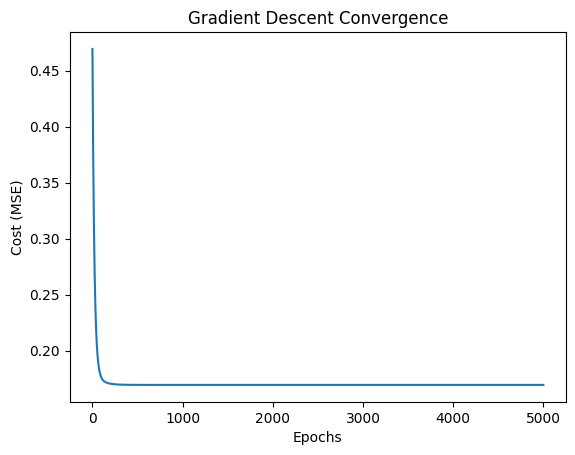

In [20]:
def gradient_descent(X, y, lr=0.01, epochs=5000):
    m, n = X.shape
    theta = np.zeros(n)
    history = []
    for _ in range(epochs):
        y_pred = X @ theta
        error = y_pred - y
        gradient = (1/m) * (X.T @ error)
        theta -= lr * gradient
        cost = (1/(2*m)) * np.sum(error**2)
        history.append(cost)
    return theta, history

theta, history = gradient_descent(X_train, y_train, lr=0.01, epochs=5000)

# Plot cost convergence
plt.plot(history)
plt.xlabel("Epochs")
plt.ylabel("Cost (MSE)")
plt.title("Gradient Descent Convergence")
plt.show()

### Explanation
- Implement gradient descent manually.
- Learning rate is moderate (0.01) since target is normalized.
- Plot cost vs epochs to check convergence.

In [21]:
# Predict normalized values
y_pred_norm = X_test @ theta

# Rescale back to original price units
y_pred = y_pred_norm * y_std + y_mean
y_test_rescaled = y_test * y_std + y_mean

# Evaluation
r2 = 1 - np.sum((y_test_rescaled - y_pred)**2) / np.sum((y_test_rescaled - np.mean(y_test_rescaled))**2)
rmse = np.sqrt(np.mean((y_test_rescaled - y_pred)**2))

print("Model Coefficients:", theta)
print("R2 Score:", r2)
print("RMSE:", rmse)

Model Coefficients: [0.08241734 0.2648987  0.04310669 0.26126527 0.20567982 0.09396694
 0.05609739 0.08013742 0.09806859 0.19074184 0.12361377 0.12237243
 0.04353487]
R2 Score: -5.271733174203876
RMSE: 1032907.4520892992


### Explanation
- Predictions are rescaled back to original price units.
- Metrics:
  - **R²**: How well the model explains variance.
  - **RMSE**: Average prediction error.

In [22]:
avg_price = np.mean(y_test_rescaled)

for i in range(len(y_test_rescaled)):
    change = ((y_pred[i] - avg_price) / avg_price) * 100
    direction = "Increase" if change > 0 else "Decrease"
    print(f"House {i+1}: Predicted Price = {y_pred[i]:.2f}, "
          f"{direction} of {abs(change):.2f}% compared to average price")

House 1: Predicted Price = 4331339.67, Increase of 59.09% compared to average price
House 2: Predicted Price = 3941750.67, Increase of 44.78% compared to average price
House 3: Predicted Price = 2851889.70, Increase of 4.75% compared to average price
House 4: Predicted Price = 2614799.09, Decrease of 3.96% compared to average price
House 5: Predicted Price = 4028562.25, Increase of 47.97% compared to average price
House 6: Predicted Price = 3772113.22, Increase of 38.55% compared to average price
House 7: Predicted Price = 3869763.82, Increase of 42.14% compared to average price
House 8: Predicted Price = 3081441.82, Increase of 13.18% compared to average price
House 9: Predicted Price = 3196483.63, Increase of 17.41% compared to average price
House 10: Predicted Price = 3114002.40, Increase of 14.38% compared to average price
House 11: Predicted Price = 4456444.12, Increase of 63.68% compared to average price
House 12: Predicted Price = 2937450.33, Increase of 7.89% compared to averag

### Explanation
- Compare each predicted price to the average test price.
- Show whether it is an **increase or decrease**.
- Display the **percentage change** for clarity.

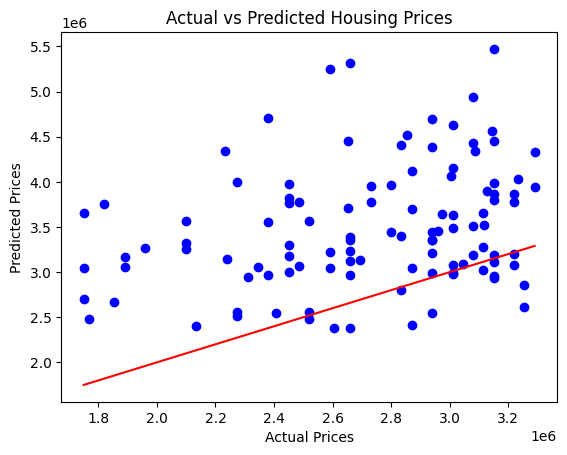

In [23]:
plt.scatter(y_test_rescaled, y_pred, color='blue')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Housing Prices")
plt.plot([min(y_test_rescaled), max(y_test_rescaled)], 
         [min(y_test_rescaled), max(y_test_rescaled)], color='red')  # perfect fit line
plt.show()

### Explanation
- Scatter plot compares actual vs predicted prices.
- Red line shows perfect fit (y = x).
- The closer points are to the line, the better the model.

### Interpretation
- Coefficients (`theta`) show feature importance:
  - Area, bedrooms, bathrooms, stories → structural features.
  - Amenities (mainroad, guestroom, basement, etc.) → lifestyle features.
  - Furnishing status → adds value to price.
- Percentage change analysis shows how each house compares to the average price in the test set.
- Scatter plot helps visualize prediction accuracy.

### SUBMISSION DETAILS:
SOURCE CODE: JUPYTER NOTEBOOK
NAME OF DATASET:Housing(1).csv
TEAM NAME WITH ROLL NUMBER: APIL KHANAL(17) & BIDHAN ARYAL(21)
